<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/bitcoin_fraud_detection_gnn/blob/main/bitcoin_fraud_detection_gnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Elliptic Bitcoin Fraud Detection with Graph Neural Networks

## Problem

Bitcoin transactions form a network rather than an independent collection of
records. Each transaction can be represented as a node, while relationships
between transactions define edges in the graph.

The goal of this project is to classify transactions as **licit** or
**illicit** using the transaction-level features provided by the Elliptic
dataset and, for the GNN models, the relationships between transactions.

## Research Question

> **Does incorporating transaction-graph structure provide useful information
> beyond transaction-level features, and does increasing GNN expressiveness
> lead to better fraud-detection performance?**

To answer this, we compare a graph-free Random Forest baseline with three
graph neural network architectures:

- **GCN** — fixed normalized neighborhood aggregation
- **GraphSAGE** — explicit self and neighbor aggregation
- **GAT** — learned attention over neighboring transactions

The comparison is designed to isolate the value of graph structure and
progressively more expressive graph aggregation mechanisms.

## Experiment Overview

The experiment follows a simple progression:

**Node features only**

Random Forest ->

**Node features + graph structure**

GCN -> GraphSAGE -> GAT

The Random Forest establishes how well transaction-level features perform
without using the graph. The GNN models then test whether incorporating
transaction relationships improves fraud detection.

## What We Will Measure

Because illicit transactions are the minority class, the primary metric is
**F1 score for the illicit class**.

We also report:

- Precision
- Recall
- PR-AUC
- ROC-AUC
- Macro F1

Classification thresholds are selected using the validation period and then
kept fixed for final test evaluation.

## Environment & Project Setup

The notebook can be run directly in Google Colab. We first clone the project
repository, install its dependencies, and then import the reusable modules
used throughout the experiment.

In [1]:
# Clone the project repository
!git clone -q https://github.com/narendrapatel6321-dotcom/bitcoin_fraud_detection_gnn.git

In [2]:
%cd bitcoin_fraud_detection_gnn

# Install project dependencies
!pip install -q -r requirements.txt

/content/bitcoin_fraud_detection_gnn


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf

from src.data import build_graph
from src.models import GCN, GraphSAGE, GAT
from src.train import train_gnn, train_rf
from src.eval_utils import (
    evaluate_gnn,
    evaluate_sklearn,
    plot_comparison_bar,
    plot_confusion_matrices,
    plot_training_history,
    select_threshold,
    set_seed,
)

In [4]:
SEED = 42

set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.20.0
NumPy version: 2.0.2


## Dataset Setup

The Elliptic dataset is not included in the repository. The notebook downloads
the dataset at runtime and extracts the three required CSV files into the
project's data directory.

The dataset contains:

- transaction-level node features
- transaction classes
- transaction-to-transaction edges

The raw data is then processed by the project's `build_graph()` pipeline.

In [5]:
import os

DATA_DIR = "data/elliptic"
os.makedirs(DATA_DIR, exist_ok=True)

### Download the Elliptic Dataset

The dataset is distributed through Kaggle.

In [6]:
!kaggle datasets download -d ellipticco/elliptic-data-set -p data/elliptic

Dataset URL: https://www.kaggle.com/datasets/ellipticco/elliptic-data-set
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 146M/146M [00:01<00:00, 84.2MB/s]



In [7]:
import zipfile

zip_path = "data/elliptic/elliptic-data-set.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

os.remove(zip_path)

print("Dataset extracted successfully.")
print(f"Data directory: {DATA_DIR}")

Dataset extracted successfully.
Data directory: data/elliptic


In [8]:
DATA_DIR = "data/elliptic/elliptic_bitcoin_dataset"

required_files = [
    "elliptic_txs_features.csv",
    "elliptic_txs_classes.csv",
    "elliptic_txs_edgelist.csv",
]

missing_files = [
    file_name
    for file_name in required_files
    if not os.path.exists(os.path.join(DATA_DIR, file_name))
]

if missing_files:
    raise FileNotFoundError(
        f"Missing dataset files: {missing_files}"
    )

print("Required dataset files:")
for file_name in required_files:
    print(f"{file_name}")

Required dataset files:
elliptic_txs_features.csv
elliptic_txs_classes.csv
elliptic_txs_edgelist.csv


The raw dataset is now available locally. We next pass it through the same
graph-building pipeline used by the project so that feature normalization,
label alignment, graph construction, and temporal masks are handled
consistently across all models.

In [9]:
graph = build_graph(DATA_DIR)

Graph  : 203,769 nodes | 468,710 undirected edges | 165 features
Train  : 26,905 nodes  (illicit=2,954)
Val    : 2,989 nodes  (illicit=508)
Test   : 16,670 nodes  (illicit=1,083)


## Dataset Overview & Temporal Split

The graph contains transaction nodes, node-level features, transaction
relationships, class labels, and a temporal index for each node.

Rather than randomly splitting transactions, we use the temporal ordering of
the dataset to separate training, validation, and test periods. This preserves
the chronological structure of the benchmark.

In [10]:
dataset_summary = pd.DataFrame(
    {
        "Property": [
            "Nodes",
            "Node features",
            "Edges",
            "Time steps",
            "Labeled nodes",
            "Illicit nodes",
            "Licit nodes",
        ],
        "Value": [
            graph.num_nodes,
            graph.x.shape[1],
            graph.num_edges,
            int(tf.reduce_max(graph.time_step).numpy()),
            int(tf.reduce_sum(
                tf.cast(graph.y != -1, tf.int32)
            ).numpy()),
            int(tf.reduce_sum(
                tf.cast(graph.y == 1, tf.int32)
            ).numpy()),
            int(tf.reduce_sum(
                tf.cast(graph.y == 0, tf.int32)
            ).numpy()),
        ],
    }
)

dataset_summary

,Property,Value
0,Nodes,203769
1,Node features,165
2,Edges,468710
3,Time steps,49
4,Labeled nodes,46564
5,Illicit nodes,4545
6,Licit nodes,42019


### Temporal Evaluation Protocol

The temporal split is fixed by the graph-building pipeline:

- **Training:** time steps 1–30
- **Validation:** time steps 31–34
- **Test:** time steps 35–49

The validation period is used for model selection and classification-threshold
selection. The test period is reserved for the final evaluation.

In [11]:
def split_summary(
    name: str,
    mask: tf.Tensor,
) -> dict:
    y_split = tf.boolean_mask(graph.y, mask).numpy()

    return {
        "Split": name,
        "Nodes": len(y_split),
        "Illicit": int((y_split == 1).sum()),
        "Licit": int((y_split == 0).sum()),
        "Illicit %": 100 * (y_split == 1).mean(),
    }


split_table = pd.DataFrame(
    [
        split_summary("Train", graph.train_mask),
        split_summary("Validation", graph.val_mask),
        split_summary("Test", graph.test_mask),
    ]
)

split_table

,Split,Nodes,Illicit,Licit,Illicit %
0,Train,26905,2954,23951,10.979372
1,Validation,2989,508,2481,16.995651
2,Test,16670,1083,15587,6.496701


### Class Distribution

Illicit transactions are substantially less frequent than licit transactions.
This class imbalance is important for both model training and evaluation.

For this reason, accuracy is not used as the primary performance measure.
Instead, we focus on illicit-class F1 and also report Precision, Recall,
PR-AUC, and ROC-AUC.

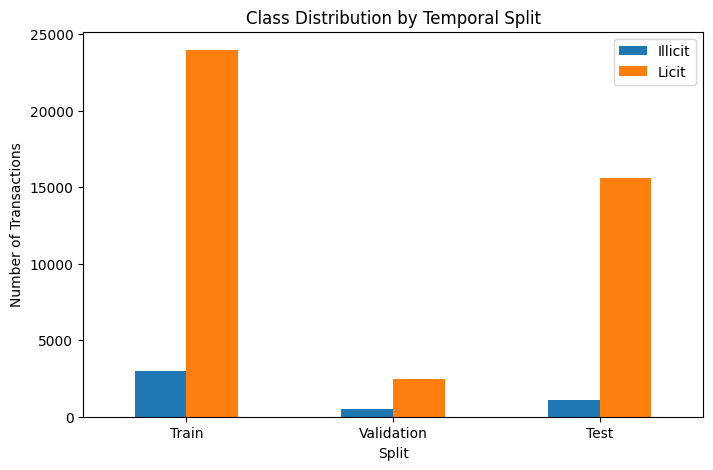

In [12]:
class_distribution = (
    split_table[
        ["Split", "Illicit", "Licit"]
    ]
    .set_index("Split")
)

class_distribution.plot(
    kind="bar",
    figsize=(8, 5),
    title="Class Distribution by Temporal Split",
    xlabel="Split",
    ylabel="Number of Transactions",
    rot=0,
);

### Transductive Setting

This experiment uses a **transductive temporal node-classification** setup.

The graph structure and node features are available to the GNN during message
passing across the complete graph. However, labels are used for supervision
only in the training period, model selection is performed on the validation
period, and the test labels are used only for the final evaluation.

Therefore, the experiment does not simulate a fully online fraud-detection
system where future graph structure is unavailable. Instead, it evaluates
whether graph structure can improve node classification under a transductive
temporal protocol.

## Why Graph Structure?

A transaction can contain useful information about itself, but transactions are
also connected through the Bitcoin transaction network.

This gives us two sources of predictive information:

1. **Node features** — properties associated with an individual transaction.
2. **Graph structure** — relationships between transactions.

The key question is therefore whether the graph provides predictive information
that is not already captured by the node features.

We test this progressively using four models.

### Model Progression

| Model | Uses Node Features | Uses Graph Structure | Main Idea |
|---|:---:|:---:|---|
| Random Forest | Yes | No | Graph-free baseline |
| GCN | Yes | Yes | Fixed normalized neighborhood aggregation |
| GraphSAGE | Yes | Yes | Separate self and neighbor aggregation |
| GAT | Yes | Yes | Learned attention over neighbors |

This progression lets us ask two related questions:

**Does graph structure help?**

Random Forest -> GCN

**Does a more expressive aggregation mechanism help?**

GCN -> GraphSAGE -> GAT

### Evaluation Strategy

All models follow the same evaluation principle.

The model is trained using the training period. The validation period is then
used for model selection and to select the probability threshold that maximizes
illicit-class F1.

Once selected, the threshold is frozen and applied to the test period.

The test set is therefore used only once for the final comparison.

### Primary Metric

The primary metric is **F1 score for the illicit class**.

F1 balances Precision and Recall:

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

This is particularly useful here because the illicit class is the minority
class and both missed illicit transactions and false alarms matter.

We additionally report:

- **Precision** — how many predicted illicit transactions are actually illicit.
- **Recall** — how many illicit transactions are detected.
- **PR-AUC** — ranking quality with emphasis on the positive class.
- **ROC-AUC** — overall ranking quality.
- **Macro F1** — average F1 across both classes.

### A Note on Fair Comparison

The GNN architectures do not need to use identical hyperparameters.

Different architectures have different optimization behavior, so each model is
allowed to use an architecture-specific training configuration.

The important constraint is that the **test period is never used to choose those
configurations or the classification threshold**.

### Experiment Configuration

Model-specific hyperparameters are defined below so that experiments can be
modified directly from the notebook without changing the reusable source
modules.

The configurations are intentionally architecture-specific rather than forcing
all models to use identical training settings.

In [32]:
# Random Forest
RF_CONFIG = {
    "n_estimators": 300,
    "max_depth": None,
    "random_state": SEED,
}

# GCN
GCN_CONFIG = {
    "hidden": 64,
    "dropout": 0.5,
    "epochs": 200,
    "lr": 0.01,
    "patience": 20,
    "weight_decay": 5e-4,
}

# GraphSAGE
SAGE_CONFIG = {
    "hidden": 64,
    "dropout": 0.5,
    "epochs": 200,
    "lr": 0.01,
    "patience": 20,
    "weight_decay": 5e-4,
}

# GAT
GAT_CONFIG = {
    "hidden": 64,
    "heads": 4,
    "dropout": 0.5,
    "epochs": 250,
    "lr": 0.005,
    "patience": 30,
    "weight_decay": 5e-4,
}

##Baseline — Random Forest

The Random Forest serves as a graph-free baseline.

It receives only the transaction-level node features and has no access to the
transaction graph. Its performance therefore provides a reference point for
evaluating whether the GNN models gain useful information from graph structure.

The Random Forest uses class-balanced training and follows the same
validation-threshold-test evaluation protocol as the GNN models.

### Baseline Configuration

We use a Random Forest with:

- 300 trees
- no maximum depth constraint
- balanced class weights
- fixed random seed for reproducibility

No graph information is provided to the model.

In [14]:
# Train the graph-free baseline
rf_model = train_rf(
    graph,
    **RF_CONFIG,
)

In [15]:
# Validation evaluation
X_val = graph.x.numpy()[graph.val_mask.numpy()]
y_val = graph.y.numpy()[graph.val_mask.numpy()]

rf_val_metrics = evaluate_sklearn(
    rf_model,
    X_val,
    y_val,
)

rf_threshold = select_threshold(
    rf_val_metrics["true"],
    rf_val_metrics["probs"],
)

print(f"Selected validation threshold: {rf_threshold:.4f}")
print(f"Validation illicit F1: {rf_val_metrics['f1_illicit']:.4f}")

Selected validation threshold: 0.3167
Validation illicit F1: 0.9636


In [16]:
# Final test evaluation
X_test = graph.x.numpy()[graph.test_mask.numpy()]
y_test = graph.y.numpy()[graph.test_mask.numpy()]

rf_metrics = evaluate_sklearn(
    rf_model,
    X_test,
    y_test,
    threshold=rf_threshold,
)

print("Random Forest — Test Results")
print(f"Illicit F1 : {rf_metrics['f1_illicit']:.4f}")
print(f"Precision  : {rf_metrics['precision']:.4f}")
print(f"Recall     : {rf_metrics['recall']:.4f}")
print(f"PR-AUC     : {rf_metrics['pr_auc']:.4f}")
print(f"ROC-AUC    : {rf_metrics['roc_auc']:.4f}")

Random Forest — Test Results
Illicit F1 : 0.7852
Precision  : 0.8553
Recall     : 0.7258
PR-AUC     : 0.7865
ROC-AUC    : 0.9226


### Baseline Takeaway

The Random Forest establishes the performance achievable using transaction-level
features without graph information.

We will use this result as the reference when evaluating the GNN models.

## Graph Convolutional Network (GCN)

The GCN is the first model that incorporates transaction relationships.

Instead of processing each transaction independently, the GCN propagates
information between connected nodes using the graph structure. Each node's
representation is therefore influenced by both its own features and information
from its neighbors.

This lets us test whether graph structure provides predictive information beyond
the node-level features used by the Random Forest.

### Architecture

The model consists of two graph convolution layers with ReLU activations and
dropout, followed by a linear classification layer.

The normalized adjacency matrix is constructed once during graph preprocessing
and reused during training.

In [17]:
gcn_model = GCN(
    hidden=GCN_CONFIG["hidden"],
    out_channels=2,
    dropout=GCN_CONFIG["dropout"],
)

### Training

The GCN is trained on the full graph in a transductive setting, but the loss is
computed only on the training-period nodes.

Validation illicit-class F1 is monitored during training, and the model weights
with the best validation F1 are restored using early stopping.

In [18]:
gcn_model, gcn_history = train_gnn(
    gcn_model,
    graph,
    graph.gcn_adj,
    epochs=GCN_CONFIG["epochs"],
    lr=GCN_CONFIG["lr"],
    patience=GCN_CONFIG["patience"],
    weight_decay=GCN_CONFIG["weight_decay"],
)

Training:  52%|█████▏    | 103/200 [00:15<00:14,  6.66ep/s, loss=0.1185, val_f1=0.7672]


Early stop at epoch 104 (best val F1=0.7773)


### Training Progress

The validation F1 curve is monitored during training to identify the point at
which the model achieves its best validation performance.

In [19]:
best_gcn_epoch = int(
    np.argmax(gcn_history["val_f1"]) + 1
)

best_gcn_val_f1 = max(
    gcn_history["val_f1"]
)

print(f"Best validation epoch: {best_gcn_epoch}")
print(f"Best validation illicit F1: {best_gcn_val_f1:.4f}")

Best validation epoch: 84
Best validation illicit F1: 0.7773


In [20]:
plot_training_history(
    {"GCN": gcn_history},
    save_dir="results/gcn",
)

Saved: results/gcn/training_history.png


### Validation Threshold Selection

After training, the validation period is used to select the probability
threshold that maximizes illicit-class F1.

The selected threshold is then kept fixed for the test evaluation.

In [21]:
gcn_val_metrics = evaluate_gnn(
    gcn_model,
    graph,
    graph.val_mask,
    graph.gcn_adj,
)

gcn_threshold = select_threshold(
    gcn_val_metrics["true"],
    gcn_val_metrics["probs"],
)

print(f"Selected threshold: {gcn_threshold:.4f}")
print(f"Validation illicit F1: {gcn_val_metrics['f1_illicit']:.4f}")

Selected threshold: 0.6392
Validation illicit F1: 0.7773


### Test Evaluation

The threshold selected on the validation period is now frozen and applied to
the test period.

In [22]:
gcn_metrics = evaluate_gnn(
    gcn_model,
    graph,
    graph.test_mask,
    graph.gcn_adj,
    threshold=gcn_threshold,
)

gcn_metrics_summary = {
    metric: gcn_metrics[metric]
    for metric in [
        "f1_illicit",
        "f1_macro",
        "precision",
        "recall",
        "pr_auc",
        "roc_auc",
        "threshold",
    ]
}

pd.DataFrame(
    [gcn_metrics_summary],
    index=["GCN"],
)

,f1_illicit,f1_macro,precision,recall,pr_auc,roc_auc,threshold
GCN,0.586764,0.780763,0.673445,0.519852,0.596055,0.893404,0.639175


### GCN Takeaway

The GCN provides the first graph-based comparison against the Random Forest.
Its final test performance will be compared with the graph-free baseline and
the more expressive GraphSAGE and GAT architectures.

## GraphSAGE

GraphSAGE extends neighborhood aggregation by explicitly combining a node's
own representation with an aggregated representation of its neighbors.

In this implementation, the neighborhood representation is computed using
mean aggregation:

$$
h_{\mathcal{N}(v)} =
\frac{1}{|\mathcal{N}(v)|}
\sum_{u \in \mathcal{N}(v)} h_u
$$

The node's own representation and the neighborhood representation are then
concatenated and transformed by a learned weight matrix.

Compared with the GCN, this provides a different way of combining self and
neighbor information.

### Architecture

The model uses two GraphSAGE layers with ReLU activations and dropout,
followed by a linear classification layer.

The row-normalized neighborhood adjacency is constructed during graph
preprocessing and reused during training.

In [23]:
sage_model = GraphSAGE(
    hidden=SAGE_CONFIG["hidden"],
    out_channels=2,
    dropout=SAGE_CONFIG["dropout"],
)

### Training

GraphSAGE is trained on the full graph in the same transductive setting as the
GCN.

The loss is computed only on training nodes, while validation illicit-class F1
is used for early stopping. The weights with the best validation F1 are
restored before final evaluation.

In [24]:
sage_model, sage_history = train_gnn(
    sage_model,
    graph,
    graph.sage_adj,
    epochs=SAGE_CONFIG["epochs"],
    lr=SAGE_CONFIG["lr"],
    patience=SAGE_CONFIG["patience"],
    weight_decay=SAGE_CONFIG["weight_decay"],
)

Training:  74%|███████▍  | 148/200 [00:17<00:06,  8.60ep/s, loss=0.0426, val_f1=0.8481]


Early stop at epoch 149 (best val F1=0.8805)


### Training Progress

We record the epoch with the best validation illicit-class F1 to make the
training behavior transparent.

In [25]:
best_sage_epoch = int(
    np.argmax(sage_history["val_f1"]) + 1
)

best_sage_val_f1 = max(
    sage_history["val_f1"]
)

print(f"Best validation epoch: {best_sage_epoch}")
print(f"Best validation illicit F1: {best_sage_val_f1:.4f}")

Best validation epoch: 129
Best validation illicit F1: 0.8805


In [26]:
plot_training_history(
    {"GraphSAGE": sage_history},
    save_dir="results/sage",
)

Saved: results/sage/training_history.png


### Validation Threshold Selection

The validation period is used to select the probability threshold that
maximizes illicit-class F1.

The selected threshold is then frozen before evaluating the test period.

In [27]:
sage_val_metrics = evaluate_gnn(
    sage_model,
    graph,
    graph.val_mask,
    graph.sage_adj,
)

sage_threshold = select_threshold(
    sage_val_metrics["true"],
    sage_val_metrics["probs"],
)

print(f"Selected threshold: {sage_threshold:.4f}")
print(f"Validation illicit F1: {sage_val_metrics['f1_illicit']:.4f}")

Selected threshold: 0.5399
Validation illicit F1: 0.8805


### Test Evaluation

The validation-selected threshold is now fixed and applied to the test period.

In [28]:
sage_metrics = evaluate_gnn(
    sage_model,
    graph,
    graph.test_mask,
    graph.sage_adj,
    threshold=sage_threshold,
)

sage_metrics_summary = {
    metric: sage_metrics[metric]
    for metric in [
        "f1_illicit",
        "f1_macro",
        "precision",
        "recall",
        "pr_auc",
        "roc_auc",
        "threshold",
    ]
}

pd.DataFrame(
    [sage_metrics_summary],
    index=["GraphSAGE"],
)

,f1_illicit,f1_macro,precision,recall,pr_auc,roc_auc,threshold
GraphSAGE,0.596524,0.784501,0.607075,0.586334,0.575909,0.875891,0.539949


### GraphSAGE Takeaway

GraphSAGE provides a second graph-based architecture with a different
neighborhood aggregation mechanism from the GCN.

Its results will be compared with the GCN to determine whether explicitly
separating self-information from neighbor information improves fraud
classification.

## Graph Attention Network (GAT)

The Graph Attention Network (GAT) learns the relative importance of neighboring
transactions during message passing.

Instead of assigning neighbors fixed aggregation weights, the model computes
an attention coefficient for each incoming edge and uses these coefficients to
weight the neighbor representations.

This allows the model to learn which connected transactions are more relevant
for the classification of a given node.

GAT therefore represents the most expressive graph aggregation mechanism in
our model progression.

### Architecture

The model uses two GAT layers.

The first layer uses multiple attention heads whose outputs are concatenated.
The second layer uses a single attention head and produces the final hidden
representation before the linear classification layer.

Dropout is applied to the node representations and attention coefficients
during training.

In [33]:
gat_model = GAT(
    hidden=GAT_CONFIG["hidden"],
    out_channels=2,
    heads=GAT_CONFIG["heads"],
    dropout=GAT_CONFIG["dropout"],
)

### Training

GAT is trained under the same transductive protocol used for GCN and GraphSAGE.

The loss is computed only on training nodes, while validation illicit-class F1
is used for early stopping. The weights corresponding to the best validation
F1 are restored before final evaluation.

The GAT configuration uses its own learning rate, dropout, number of attention
heads, and training budget because its optimization behavior differs from the
simpler aggregation models.

In [34]:
gat_model, gat_history = train_gnn(
    gat_model,
    graph,
    graph.gat_edge_index,
    epochs=GAT_CONFIG["epochs"],
    lr=GAT_CONFIG["lr"],
    patience=GAT_CONFIG["patience"],
    weight_decay=GAT_CONFIG["weight_decay"],
)

Training:  74%|███████▎  | 184/250 [01:09<00:24,  2.64ep/s, loss=0.3108, val_f1=0.7508]


Early stop at epoch 185 (best val F1=0.7602)


### Training Progress

We record the epoch with the best validation illicit-class F1 to make the
training behavior transparent.

In [35]:
best_gat_epoch = int(
    np.argmax(gat_history["val_f1"]) + 1
)

best_gat_val_f1 = max(
    gat_history["val_f1"]
)

print(f"Best validation epoch: {best_gat_epoch}")
print(f"Best validation illicit F1: {best_gat_val_f1:.4f}")

Best validation epoch: 155
Best validation illicit F1: 0.7602


In [36]:
plot_training_history(
    {"GAT": gat_history},
    save_dir="results/gat",
)

Saved: results/gat/training_history.png


### Validation Threshold Selection

The validation period is used to select the probability threshold that
maximizes illicit-class F1.

The selected threshold is then frozen before evaluating the test period.

In [37]:
gat_val_metrics = evaluate_gnn(
    gat_model,
    graph,
    graph.val_mask,
    graph.gat_edge_index,
)

gat_threshold = select_threshold(
    gat_val_metrics["true"],
    gat_val_metrics["probs"],
)

print(f"Selected threshold: {gat_threshold:.4f}")
print(f"Validation illicit F1: {gat_val_metrics['f1_illicit']:.4f}")

Selected threshold: 0.7926
Validation illicit F1: 0.7602


### Test Evaluation

The validation-selected threshold is now fixed and applied to the test period.

In [38]:
gat_metrics = evaluate_gnn(
    gat_model,
    graph,
    graph.test_mask,
    graph.gat_edge_index,
    threshold=gat_threshold,
)

gat_metrics_summary = {
    metric: gat_metrics[metric]
    for metric in [
        "f1_illicit",
        "f1_macro",
        "precision",
        "recall",
        "pr_auc",
        "roc_auc",
        "threshold",
    ]
}

pd.DataFrame(
    [gat_metrics_summary],
    index=["GAT"],
)

,f1_illicit,f1_macro,precision,recall,pr_auc,roc_auc,threshold
GAT,0.426338,0.69378,0.437743,0.415512,0.342007,0.863447,0.792624


### GAT Takeaway

GAT completes the model progression by allowing the model to learn
neighbor-specific importance during message passing.

The final comparison will determine whether this additional expressiveness
translates into better fraud-detection performance.

## Model Comparison

All four models have now been evaluated on the same test period.

The classification threshold for each model was selected independently using
the validation period and then kept fixed for test evaluation.

We use **illicit-class F1** as the primary comparison metric, with Precision,
Recall, PR-AUC, and ROC-AUC providing additional context.

In [39]:
results = {
    "Random Forest": rf_metrics,
    "GCN": gcn_metrics,
    "GraphSAGE": sage_metrics,
    "GAT": gat_metrics,
}

results_table = pd.DataFrame(
    {
        "Model": list(results.keys()),
        "Illicit F1": [
            metrics["f1_illicit"]
            for metrics in results.values()
        ],
        "Macro F1": [
            metrics["f1_macro"]
            for metrics in results.values()
        ],
        "Precision": [
            metrics["precision"]
            for metrics in results.values()
        ],
        "Recall": [
            metrics["recall"]
            for metrics in results.values()
        ],
        "PR-AUC": [
            metrics["pr_auc"]
            for metrics in results.values()
        ],
        "ROC-AUC": [
            metrics["roc_auc"]
            for metrics in results.values()
        ],
        "Threshold": [
            metrics["threshold"]
            for metrics in results.values()
        ],
    }
)

results_table = (
    results_table
    .sort_values("Illicit F1", ascending=False)
    .reset_index(drop=True)
)

results_table

,Model,Illicit F1,Macro F1,Precision,Recall,PR-AUC,ROC-AUC,Threshold
0,Random Forest,0.785215,0.885747,0.855277,0.725762,0.786475,0.922601,0.316667
1,GraphSAGE,0.596524,0.784501,0.607075,0.586334,0.575909,0.875891,0.539949
2,GCN,0.586764,0.780763,0.673445,0.519852,0.596055,0.893404,0.639175
3,GAT,0.426338,0.693780,0.437743,0.415512,0.342007,0.863447,0.792624


### Primary Metric Comparison

The models are ranked by illicit-class F1 because detecting the minority illicit
class is the primary objective of the experiment.

The remaining metrics help distinguish whether differences in F1 arise from
different Precision–Recall trade-offs or reflect broader differences in ranking
quality.

In [40]:
plot_comparison_bar(
    results,
    save_dir="results",
)

Saved: results/model_comparison.png


### Confusion Matrices

Confusion matrices provide a direct view of the classification trade-off
between missed illicit transactions and false illicit predictions.

In [41]:
plot_confusion_matrices(
    results,
    save_dir="results",
)

Saved: results/confusion_matrices.png


### Validation Training Curves

The validation curves show how illicit-class F1 evolved during training for the
three GNN architectures.

The curves are useful for understanding convergence and whether a model's best
validation performance occurred substantially earlier than its configured
training budget.

In [42]:
plot_training_history(
    {
        "GCN": gcn_history,
        "GraphSAGE": sage_history,
        "GAT": gat_history,
    },
    save_dir="results",
)

Saved: results/training_history.png


In [43]:
training_summary = pd.DataFrame(
    [
        {
            "Model": "GCN",
            "Best Epoch": best_gcn_epoch,
            "Best Validation F1": best_gcn_val_f1,
        },
        {
            "Model": "GraphSAGE",
            "Best Epoch": best_sage_epoch,
            "Best Validation F1": best_sage_val_f1,
        },
        {
            "Model": "GAT",
            "Best Epoch": best_gat_epoch,
            "Best Validation F1": best_gat_val_f1,
        },
    ]
)

training_summary

,Model,Best Epoch,Best Validation F1
0,GCN,84,0.777300
1,GraphSAGE,129,0.880539
2,GAT,155,0.760225


### Comparing Model Complexity and Performance

The final comparison should not assume that the most complex model is the best
model.

If a simpler model achieves similar or better performance, that is an important
result: the additional complexity of a more expressive GNN may not provide
enough predictive benefit to justify its cost.

Conversely, if the more expressive models consistently improve illicit-class F1
and PR-AUC, this provides evidence that learning richer graph interactions is
useful for this dataset.

## Results & Discussion

The final results allow us to evaluate two questions:

1. Does incorporating graph structure improve fraud detection over the
   graph-free Random Forest baseline?

2. Does increasing the expressiveness of the graph aggregation mechanism
   improve performance?

In [44]:
best_model = results_table.iloc[0]

rf_result = results_table[
    results_table["Model"] == "Random Forest"
].iloc[0]

best_gnn = (
    results_table[
        results_table["Model"].isin(
            ["GCN", "GraphSAGE", "GAT"]
        )
    ]
    .sort_values("Illicit F1", ascending=False)
    .iloc[0]
)

best_model_name = best_model["Model"]
best_gnn_name = best_gnn["Model"]

rf_f1 = rf_result["Illicit F1"]
best_gnn_f1 = best_gnn["Illicit F1"]

gnn_improvement = best_gnn_f1 - rf_f1

print(f"Best overall model: {best_model_name}")
print(f"Best GNN: {best_gnn_name}")
print(f"Best GNN F1 - RF F1: {gnn_improvement:+.4f}")

Best overall model: Random Forest
Best GNN: GraphSAGE
Best GNN F1 - RF F1: -0.1887


### Performance Relative to the Random Forest

The Random Forest provides the reference point because it uses only
transaction-level features.

The best-performing GNN can therefore be compared directly against it to
assess whether incorporating graph structure provides additional predictive
signal.

In [45]:
comparison_table = results_table.copy()

comparison_table["F1 vs RF"] = (
    comparison_table["Illicit F1"] - rf_f1
)

comparison_table[
    [
        "Model",
        "Illicit F1",
        "F1 vs RF",
        "Precision",
        "Recall",
        "PR-AUC",
        "ROC-AUC",
    ]
]

,Model,Illicit F1,F1 vs RF,Precision,Recall,PR-AUC,ROC-AUC
0,Random Forest,0.785215,0.000000,0.855277,0.725762,0.786475,0.922601
1,GraphSAGE,0.596524,-0.188691,0.607075,0.586334,0.575909,0.875891
2,GCN,0.586764,-0.198451,0.673445,0.519852,0.596055,0.893404
3,GAT,0.426338,-0.358877,0.437743,0.415512,0.342007,0.863447


### Precision–Recall Trade-off

F1 alone does not explain how a model achieves its performance.

A model with higher Recall may identify more illicit transactions but also
produce more false positives. Conversely, higher Precision may come at the
cost of missing more illicit transactions.

Precision and Recall should therefore be interpreted together with illicit
F1 and PR-AUC.

In [46]:
precision_recall_table = results_table[
    [
        "Model",
        "Illicit F1",
        "Precision",
        "Recall",
        "PR-AUC",
    ]
].copy()

precision_recall_table

,Model,Illicit F1,Precision,Recall,PR-AUC
0,Random Forest,0.785215,0.855277,0.725762,0.786475
1,GraphSAGE,0.596524,0.607075,0.586334,0.575909
2,GCN,0.586764,0.673445,0.519852,0.596055
3,GAT,0.426338,0.437743,0.415512,0.342007


### Model Complexity vs. Performance

The model progression increases the complexity of graph aggregation:

**GCN -> GraphSAGE -> GAT**

However, greater architectural complexity does not automatically imply better
performance.

The final model choice should therefore consider both predictive performance
and the additional complexity introduced by the architecture.

## Limitations & Scope

This experiment provides a controlled comparison of graph-free and graph-based
models on the Elliptic benchmark, but several limitations should be kept in
mind.

### Transductive Setting

The experiment uses a transductive temporal setup. The complete graph structure
and node features are available during GNN message passing, including
information from future time steps. Future labels are not used for training or
model selection.

Therefore, the experiment should not be interpreted as a fully online fraud
detection system where only information available before a transaction occurs
is accessible.

### Temporal Evaluation

The train, validation, and test periods follow the temporal ordering of the
dataset rather than random sampling. However, the experiment uses a single
fixed temporal split, so performance may vary under different temporal
windows.

### Dataset Dependence

Results are based on the Elliptic Bitcoin transaction benchmark and may not
generalize directly to other cryptocurrencies, transaction networks, or
real-world fraud detection systems.

### Model Selection

Hyperparameters and classification thresholds are selected using the
validation period. The test period is reserved for final evaluation and is not
used for model selection.

### Evaluation Metrics

Illicit-class F1 is the primary metric, but no single metric completely
captures the operational cost of false positives and false negatives in a
real fraud detection system.

## Conclusion

This project evaluated whether transaction-graph structure provides useful
information beyond transaction-level features for Bitcoin illicit transaction
classification.

We compared a graph-free Random Forest baseline with three GNN architectures:
GCN, GraphSAGE, and GAT. All models were evaluated under the same transductive
temporal protocol, with classification thresholds selected using the validation
period and final performance measured on the held-out test period.

The results show **[insert the main finding from the final results]**.

In particular, **[state whether the best GNN improved upon the Random Forest
and which GNN performed best]**.

The experiment therefore suggests that **[state what the results imply about
the usefulness of graph structure and/or increasingly expressive aggregation]**.

Overall, the comparison demonstrates the trade-off between model complexity
and predictive performance rather than assuming that a more sophisticated GNN
will necessarily outperform a simpler baseline.